In [ ]:
!pip install faiss-cpu nltk

# Introducción

La **recuperación de información basada en preguntas (Retrieval-based Question Answering)** es una técnica fundamental en el procesamiento del lenguaje natural que permite, dada una pregunta formulada en lenguaje natural, encontrar el fragmento de texto (contexto) más relevante que podría contener la respuesta dentro de una colección de documentos.

**Por ejemplo**, ante una pregunta como:

> *¿Qué influencia convirtió Japón en una nación industrial?*

Un sistema de recuperación bien construido debería ser capaz de identificar, entre miles de contextos posibles, el fragmento que contiene la respuesta: *"otra de las influencias foráneas fue la de origen occidental, lo que convirtió al país en una nación industrial"*.

A diferencia de los sistemas generativos (como los LLMs), los sistemas de recuperación **no generan texto nuevo**, sino que **buscan y devuelven fragmentos existentes** de una base de conocimiento. Esto los hace especialmente útiles en escenarios donde la precisión y trazabilidad de la información son críticas.

El enfoque que seguiremos se basa en la **búsqueda semántica mediante embeddings**: tanto las preguntas como los contextos se representan como vectores densos en un espacio de alta dimensionalidad, y se utiliza la similitud entre estos vectores para encontrar los contextos más relevantes.

**¿Cómo funciona un sistema de recuperación basado en embeddings?**

El flujo de un sistema de recuperación semántica se puede resumir en los siguientes pasos:

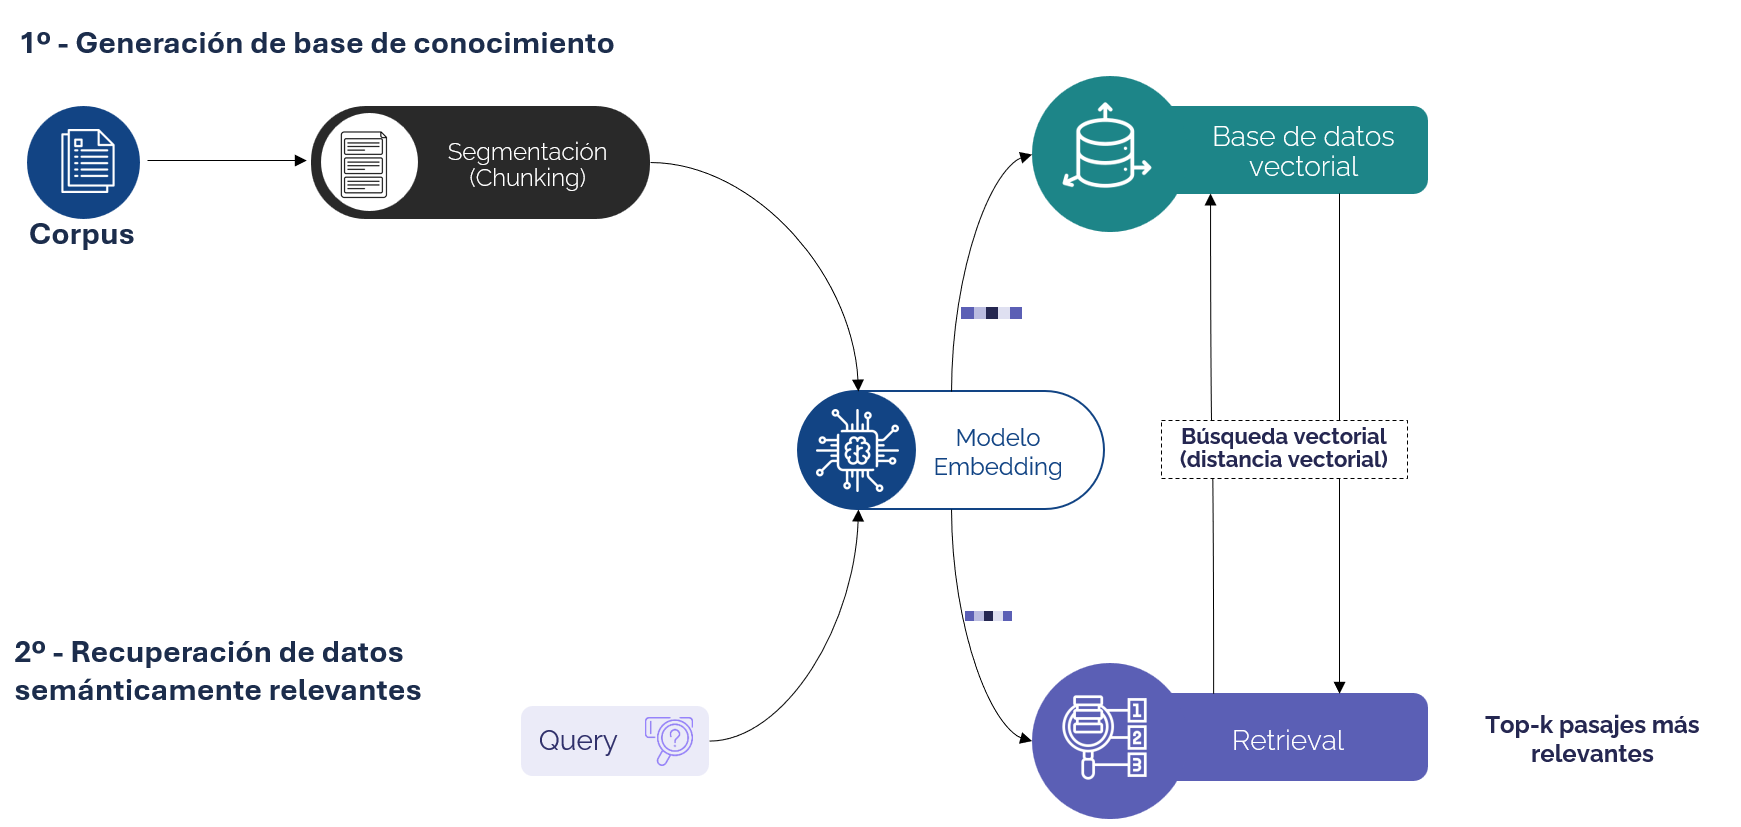


**¿Por qué es útil?**
- **Buscadores semánticos**: Permiten encontrar documentos relevantes basándose en el significado de la consulta, no solo en coincidencias de palabras clave.
- **Asistentes virtuales y chatbots**: Permiten responder preguntas de usuarios a partir de bases de conocimiento internas.
- **Sistemas RAG (Retrieval-Augmented Generation)**: Los sistemas modernos de IA generativa combinan la recuperación de documentos relevantes con la generación de respuestas, mejorando la precisión y reduciendo las alucinaciones.


En este notebook, construiremos y evaluaremos un sistema de recuperación semántica utilizando el corpus **SQAC** (Spanish Question-Answering Corpus) y dos modelos de sentence-transformers multilingües.

# Proceso Resumido

En este notebook se llevará a cabo el proceso completo para construir y evaluar un sistema de **recuperación de contextos** basado en embeddings.

Para ello, utilizaremos **modelos de sentence-transformers** que generan representaciones vectoriales densas de textos, y una **base de datos vectorial utilizando la librería [FAISS](https://github.com/facebookresearch/faiss)** para realizar búsquedas eficientes por similitud.

El flujo básico será el siguiente:

1. **Preparación de datos**: Descargaremos el [corpus SQAC](https://huggingface.co/datasets/PlanTL-GOB-ES/SQAC) para trabajar con el conjunto de test.  En esta fase prepararemos los datos para la tarea de recuperación de infromación. Esto implica extraer los contextos únicos y crear un mapeo entre cada pregunta y su contexto correcto (*ground truth*). Trabajaremos con dos niveles de granularidad a nivel de contextos:
   - **Contexto completo**: Cada contexto/documento se trata como una unidad indivisible. El sistema debe encontrar el documento que contiene la respuesta.
   - **Chunk (frase)**: Cada documento se divide en frases individuales. El sistema debe encontrar la frase concreta que contiene la respuesta, lo cual es más realista para pipelines en el mundo real.


2. **Generación de la base de datos vectorial (FAISS)**: Codificaremos todos los contextos utilizando un modelo de sentence-transformers para obtener sus embeddings. Estos vectores se almacenarán en un índice FAISS que permitirá realizar búsquedas eficientes por similitud coseno.

3. **Sistema de recuperación**: Construiremos una clase de Python que, dada una pregunta, se codifique con el mismo modelo y busque en el índice FAISS los *k* contextos más similares.

4. **Evaluación**: Mediremos el rendimiento del sistema utilizando métricas estándar de recuperación de información: **Recall@k**, **MRR (Mean Reciprocal Rank)** y **Accuracy@k**.

En este ejercicio testearemos dos modelos de embeddings pre-entrenados de diferente calidad (como se puede observar en el [MTEB benchmark](https://huggingface.co/spaces/mteb/leaderboard):
- `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`
- `intfloat/multilingual-e5-small`

# 1. Descarga y preparación de datos

Para evaluar nuestro sistema de recuperación utilizaremos el [**corpus SQAC (Spanish Question-Answering Corpus)**](https://huggingface.co/datasets/PlanTL-GOB-ES/SQAC), un dataset de preguntas y respuestas extractivas en español.

El dataset contiene 6.247 contextos y 18.817 preguntas con sus respectivas respuestas. Cada ejemplo incluye:

- **`id`**: Identificador único de la pregunta.
- **`title`**: Título del artículo de donde proviene el contexto.
- **`context`**: Fragmento de texto que contiene la respuesta.
- **`question`**: Pregunta formulada en lenguaje natural.
- **`answers`**: Respuesta(s) extraída(s) del contexto, con su posición de inicio.

Las fuentes de los contextos incluyen artículos de la Wikipedia en español, Wikinews y el corpus AnCora.

En nuestro caso, trabajaremos exclusivamente con el **conjunto de test** (1.910 ejemplos) para evaluar la capacidad de los modelos de recuperar el contexto correcto dada una pregunta.

En primer lugar, descargamos el conjunto de test del corpus SQAC. En una situación normal, utilizariamos la librería `datasets` de Hugging Face; sin embargo, dado que estamos trabajando con un conjunto de datos antiguo, no tiene compatibilidad con la nueva versión de la librería, por lo que uitilizaremos otro formato:

In [ ]:
from datasets import load_dataset
import requests
from datasets import Dataset

def load_sqac_split(split="test"):
    url = f"https://huggingface.co/datasets/PlanTL-GOB-ES/SQAC/resolve/main/{split}.json"
    data = requests.get(url).json()

    rows = []

    for article in data["data"]:
        title = article.get("title", "").strip()

        for paragraph in article["paragraphs"]:
            context = paragraph["context"].strip()

            for qa in paragraph["qas"]:
                rows.append({
                    "id": qa["id"],
                    "title": title,
                    "context": context,
                    "question": qa["question"].strip(),
                    "answers": {
                        "text": [a["text"].strip() for a in qa["answers"]],
                        "answer_start": [a["answer_start"] for a in qa["answers"]],
                    }
                })

    return Dataset.from_list(rows)

dataset = load_sqac_split("test")
dataset

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 1910
})

Podemos explorar la estructura del dataset:

In [ ]:
print(f"Número de ejemplos en el conjunto de test: {len(dataset)}")
print(f"Columnas del dataset: {dataset.column_names}")
print(f"Tipos de cada columna: {dataset.features}")

Número de ejemplos en el conjunto de test: 1910
Columnas del dataset: ['id', 'title', 'context', 'question', 'answers']
Tipos de cada columna: {'id': Value('string'), 'title': Value('string'), 'context': Value('string'), 'question': Value('string'), 'answers': {'answer_start': List(Value('int64')), 'text': List(Value('string'))}}


Veamos un ejemplo del dataset para entender su estructura:

In [ ]:
import pandas as pd

# Mostramos los primeros ejemplos
ejemplo = dataset[0]
print(f"ID: {ejemplo['id']}")
print(f"Título: {ejemplo['title']}")
print(f"Contexto: {ejemplo['context'][:200]}...")
print(f"Pregunta: {ejemplo['question']}")
print(f"Respuesta: {ejemplo['answers']['text']}")
print(f"Posición de inicio: {ejemplo['answers']['answer_start']}")

ID: 56ea5a6b-c494-43fb-8af9-f084e1b3ff11
Título: Célula
Contexto: La célula (del latín cellula, diminutivo de cella, ‘celda’)​ es la unidad morfológica y funcional de todo ser vivo. De hecho, la célula es el elemento de menor tamaño que puede considerarse vivo.​ De ...
Pregunta: ¿Cuál es el nombre que se le da a la unidad morfológica y funcional de los seres vivos?
Respuesta: ['célula']
Posición de inicio: [3]


Se observa que cada elemento del dataset es una pregunta sobre un contexto. La respuesta exacta viene indicada en el campo "answers"-"text", pudiendo conocer el índice de comienzo en el contexto.

## Exploración de datos

### Exploración de datos a nivel documento

Antes de preparar los datos para la tarea de recuperación, vamos a explorar algunas características del dataset:

In [ ]:
# Número de contextos únicos
contextos_unicos = set(dataset["context"])
print(f"Número total de ejemplos (preguntas): {len(dataset)}")
print(f"Número de contextos únicos: {len(contextos_unicos)}")
print(f"Ratio preguntas/contexto: {len(dataset) / len(contextos_unicos):.2f}")

# Número de títulos únicos
titulos_unicos = set(dataset["title"])
print(f"Número de artículos (títulos) únicos: {len(titulos_unicos)}")

Número total de ejemplos (preguntas): 1910
Número de contextos únicos: 634
Ratio preguntas/contexto: 3.01
Número de artículos (títulos) únicos: 383


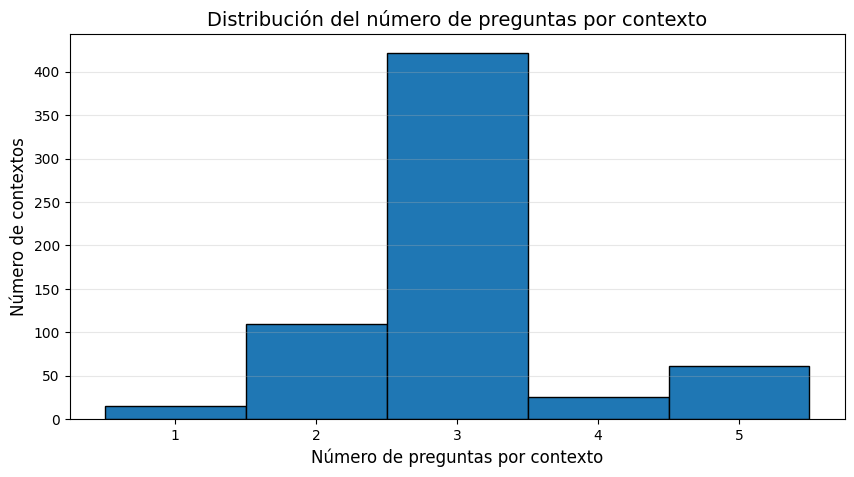


Estadísticas de preguntas por contexto:
  Mínimo: 1
  Máximo: 5
  Media: 3.01
  Mediana: 3.0


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Calculamos el número de preguntas por contexto
preguntas_por_contexto = Counter(dataset["context"])
frecuencias = list(preguntas_por_contexto.values())

plt.figure(figsize=(10, 5))
plt.hist(frecuencias, bins=range(1, max(frecuencias) + 2), edgecolor='black', align='left')
plt.xlabel('Número de preguntas por contexto', fontsize=12)
plt.ylabel('Número de contextos', fontsize=12)
plt.title('Distribución del número de preguntas por contexto', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"\nEstadísticas de preguntas por contexto:")
import numpy as np
print(f"  Mínimo: {min(frecuencias)}")
print(f"  Máximo: {max(frecuencias)}")
print(f"  Media: {np.mean(frecuencias):.2f}")
print(f"  Mediana: {np.median(frecuencias):.1f}")

### Exploración a nivel de chunk (frase)

Para entender cómo se comportaría la recuperación a nivel de frase, analizamos la segmentación de los contextos en frases utilizando `nltk.sent_tokenize`:


In [ ]:
import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

# Dividir cada contexto único en frases
contextos_lista = list(contextos_unicos)
chunks_por_contexto = [sent_tokenize(ctx, language='spanish') for ctx in contextos_lista]
num_chunks = [len(sents) for sents in chunks_por_contexto]
todas_las_frases = [sent for sents in chunks_por_contexto for sent in sents]
longitudes_frases = [len(sent) for sent in todas_las_frases]
longitudes_palabras = [len(sent.split()) for sent in todas_las_frases]


In [ ]:

print(f"Total de chunks (frases) generados: {len(todas_las_frases)}")
print(f"\nChunks por contexto:")
print(f"  Mínimo: {min(num_chunks)}")
print(f"  Máximo: {max(num_chunks)}")
print(f"  Media: {np.mean(num_chunks):.2f}")
print(f"  Mediana: {np.median(num_chunks):.1f}")

Total de chunks (frases) generados: 4571

Chunks por contexto:
  Mínimo: 1
  Máximo: 37
  Media: 7.21
  Mediana: 6.0


## Preparación de datos para recuperación

Para evaluar un sistema de recuperación necesitamos preparar los datos de forma específica. La idea es la siguiente:

1. **Extraer los contextos únicos**: Dado que múltiples preguntas pueden compartir el mismo contexto, necesitamos obtener la lista de contextos sin duplicados. Estos contextos formarán nuestra "base de conocimiento" sobre la que se realizará la búsqueda.

2. **Crear el mapeo pregunta → contexto correcto**: Para cada pregunta, necesitamos saber cuál es el índice del contexto correcto en nuestra lista de contextos únicos. Este mapeo será nuestro *ground truth* para la evaluación.

De esta forma, podremos medir si el sistema de recuperación es capaz de encontrar el contexto correcto (el que contiene la respuesta) dada una pregunta.

In [ ]:
def prepare_retrieval_data(dataset):
    """
    Prepara los datos del corpus SQAC para la tarea de recuperación.

    A partir del dataset original, extrae los contextos únicos y crea
    un mapeo entre cada pregunta y el índice de su contexto correcto.

    Args:
        dataset: Dataset de Hugging Face con campos 'context' y 'question'.

    Returns:
        contexts (list[str]): Lista de contextos únicos (corpus de búsqueda).
        questions (list[str]): Lista de preguntas.
        ground_truth (list[int]): Índice del contexto correcto para cada pregunta.
    """
    # Extraer contextos únicos manteniendo el orden de aparición
    context_to_idx = {}
    contexts = []
    for ctx in dataset["context"]:
        if ctx not in context_to_idx:
            context_to_idx[ctx] = len(contexts)
            contexts.append(ctx)

    # Crear el mapeo pregunta -> índice del contexto correcto
    questions = []
    ground_truth = []
    for example in dataset:
        questions.append(example["question"])
        ground_truth.append(context_to_idx[example["context"]])

    return contexts, questions, ground_truth

In [ ]:
# Preparamos los datos para la evaluación de recuperación
contexts, questions, ground_truth = prepare_retrieval_data(dataset)

print(f"Número de contextos únicos (corpus de búsqueda): {len(contexts)}")
print(f"Número de preguntas (queries): {len(questions)}")
print(f"\nEjemplo:")
print(f"  Pregunta: {questions[1]}")
print(f"  Índice del contexto correcto: {ground_truth[1]}")
print(f"  Contexto correcto: {contexts[ground_truth[1]][:150]}...")

Número de contextos únicos (corpus de búsqueda): 634
Número de preguntas (queries): 1910

Ejemplo:
  Pregunta: ¿De dónde proviene el término "célula")
  Índice del contexto correcto: 0
  Contexto correcto: La célula (del latín cellula, diminutivo de cella, ‘celda’)​ es la unidad morfológica y funcional de todo ser vivo. De hecho, la célula es el elemento...


## Preparación de datos a nivel de chunk (frase)

Para una evaluación más realista, dividimos cada contexto en **frases individuales** (chunks) utilizando `nltk.sent_tokenize`. Esto simula un escenario de RAG donde los documentos se fragmentan antes de indexarlos.

El proceso es el siguiente:

1. **Dividir cada contexto en frases**: Utilizamos el tokenizador de frases de NLTK con soporte para español.
2. **Rastrear las posiciones de cada frase**: Para cada frase, guardamos su posición (offset de caracteres) dentro del contexto original.
3. **Mapear respuestas a chunks**: Para cada pregunta, identificamos qué frase(s) contienen la respuesta. Dado que una respuesta puede cruzar el límite entre dos frases, marcamos como correctas **todas las frases que solapan** con el span de la respuesta (ground truth multi-label).

In [ ]:
from nltk.tokenize import sent_tokenize

def prepare_retrieval_data_chunks(dataset):
    """
    Prepara los datos del corpus SQAC para recuperación a nivel de chunk (frase).

    Cada contexto se divide en frases y se identifica(n) la(s) frase(s) que
    contienen la respuesta, permitiendo ground truth multi-label.

    Args:
        dataset: Dataset de Hugging Face con campos 'context', 'question' y 'answers'.

    Returns:
        chunks (list[str]): Lista de todas las frases de todos los contextos.
        questions (list[str]): Lista de preguntas.
        ground_truth (list[set[int]]): Para cada pregunta, conjunto de índices de los
            chunks que contienen (parte de) la respuesta.
        chunk_metadata (list[dict]): Metadatos de cada chunk (índice del contexto
            original, posición de inicio y fin en caracteres).
    """
    # Extraer contextos únicos manteniendo el orden de aparición
    context_to_idx = {}
    unique_contexts = []
    for ctx in dataset["context"]:
        if ctx not in context_to_idx:
            context_to_idx[ctx] = len(unique_contexts)
            unique_contexts.append(ctx)

    # Dividir cada contexto en frases y rastrear posiciones
    chunks = []
    chunk_metadata = []
    context_chunks_map = {}  # context_idx -> list of (chunk_idx, char_start, char_end)

    for ctx_idx, ctx in enumerate(unique_contexts):
        sentences = sent_tokenize(ctx, language='spanish')
        ctx_chunks = []
        current_pos = 0
        for sent in sentences:
            start = ctx.find(sent, current_pos)
            end = start + len(sent)
            chunk_idx = len(chunks)
            chunks.append(sent)
            chunk_metadata.append({
                'context_idx': ctx_idx,
                'char_start': start,
                'char_end': end
            })
            ctx_chunks.append((chunk_idx, start, end))
            current_pos = end
        context_chunks_map[ctx_idx] = ctx_chunks

    # Para cada pregunta, encontrar qué chunk(s) contienen la respuesta
    questions = []
    ground_truth = []

    for example in dataset:
        questions.append(example["question"])
        ctx_idx = context_to_idx[example["context"]]

        answer_starts = example["answers"]["answer_start"]
        answer_texts = example["answers"]["text"]

        correct_chunks = set()
        for ans_start, ans_text in zip(answer_starts, answer_texts):
            ans_end = ans_start + len(ans_text)
            # Buscar chunks que solapen con el span de la respuesta
            for chunk_idx, chunk_start, chunk_end in context_chunks_map[ctx_idx]:
                if chunk_start < ans_end and chunk_end > ans_start:
                    correct_chunks.add(chunk_idx)

        ground_truth.append(correct_chunks)

    return chunks, questions, ground_truth, chunk_metadata

In [ ]:
# Preparamos los datos a nivel de chunk
chunks, questions_chunks, ground_truth_chunks, chunk_metadata = prepare_retrieval_data_chunks(dataset)

print(f"Número de chunks (frases) en el corpus: {len(chunks)}")
print(f"Número de preguntas: {len(questions_chunks)}")

# Estadísticas del ground truth multi-label
n_chunks_por_pregunta = [len(gt) for gt in ground_truth_chunks]
print(f"\nChunks correctos por pregunta:")
print(f"  Media: {np.mean(n_chunks_por_pregunta):.2f}")
print(f"  Máximo: {max(n_chunks_por_pregunta)}")
print(f"  Preguntas con 1 chunk correcto: {sum(1 for n in n_chunks_por_pregunta if n == 1)} ({sum(1 for n in n_chunks_por_pregunta if n == 1)/len(n_chunks_por_pregunta)*100:.1f}%)")
print(f"  Preguntas con >1 chunk correcto: {sum(1 for n in n_chunks_por_pregunta if n > 1)} ({sum(1 for n in n_chunks_por_pregunta if n > 1)/len(n_chunks_por_pregunta)*100:.1f}%)")

Número de chunks (frases) en el corpus: 4571
Número de preguntas: 1910

Chunks correctos por pregunta:
  Media: 1.00
  Máximo: 2
  Preguntas con 1 chunk correcto: 1907 (99.8%)
  Preguntas con >1 chunk correcto: 3 (0.2%)


En el siguiente ejemplo se obserca como, aunque la respuesta a la pregunta con índice 4 se encuentra en el contexto con idx 1. Si trabajamos a nivel de chunk, es el chunk número 8 del documento con idx 1 donde aparecería:

In [ ]:
# Ejemplo detallado: un contexto dividido en chunks con la respuesta resaltada
ejemplo_idx = 4
ejemplo = dataset[ejemplo_idx]
ctx_idx = chunk_metadata[list(ground_truth_chunks[ejemplo_idx])[0]]['context_idx']

print(f"Pregunta: {ejemplo['question']}")
print(f"Respuesta: {ejemplo['answers']['text']}")
print(f"Contexto original (idx={ctx_idx}):")
print(f"  {ejemplo['context'][:200]}...")
print(f"\nChunks del contexto:")
print("-" * 80)

# Encontrar todos los chunks de este contexto
chunks_de_contexto = [(i, c, m) for i, (c, m) in enumerate(zip(chunks, chunk_metadata))
                       if m['context_idx'] == ctx_idx]

gt_set = ground_truth_chunks[ejemplo_idx]
for chunk_idx, chunk_text, meta in chunks_de_contexto:
    marker = " >> " if chunk_idx in gt_set else "    "
    print(f"{marker}[Chunk {chunk_idx}] (chars {meta['char_start']}-{meta['char_end']})")
    print(f"{marker}{chunk_text[:120]}{'...' if len(chunk_text) > 120 else ''}")
    print()

Pregunta: ¿Cómo se llaman las células que necesitan las neuronas para sobrevivir?
Respuesta: ['gliales']
Contexto original (idx=1):
  La célula eucariota 
Las células eucariotas son el exponente de la complejidad celular actual. Presentan una estructura básica relativamente estable caracterizada por la presencia de distintos tipos d...

Chunks del contexto:
--------------------------------------------------------------------------------
    [Chunk 4] (chars 0-94)
    La célula eucariota 
Las células eucariotas son el exponente de la complejidad celular actual.

    [Chunk 5] (chars 95-318)
    Presentan una estructura básica relativamente estable caracterizada por la presencia de distintos tipos de orgánulos int...

    [Chunk 6] (chars 319-428)
    Especialmente en los organismos pluricelulares, las células pueden alcanzar un alto grado de especialización.

    [Chunk 7] (chars 429-562)
    Dicha especialización o diferenciación es tal que, en algunos casos, compromete la propia viabi

# 2. Generación de la base de datos vectorial (FAISS)

[**FAISS (Facebook AI Similarity Search)**](https://github.com/facebookresearch/faiss) es una librería desarrollada por Meta AI para la búsqueda eficiente de vectores similares en grandes colecciones de datos. Es ampliamente utilizada en sistemas de recuperación de información y recomendación.

El proceso para construir un índice FAISS consiste en:

1. **Codificar los documentos**: Utilizar un modelo de embeddings (en nuestro caso, un sentence-transformer) para convertir cada contexto en un vector denso de dimensión fija.

2. **Normalizar los vectores**: Para poder utilizar la similitud coseno, normalizamos los vectores a norma unitaria (L2). De esta forma, el producto escalar entre vectores normalizados equivale a la similitud coseno.

3. **Crear el índice**: Utilizamos `faiss.IndexFlatIP` (Inner Product) que realiza una búsqueda exacta por producto escalar. Dado que los vectores están normalizados, esto es equivalente a buscar por similitud coseno.

En este notebook evaluaremos dos modelos de sentence-transformers multilingües:

- **`sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`**: Un modelo multilingüe compacto basado en MiniLM, entrenado para generar embeddings de paráfrasis en más de 50 idiomas.

- **`intfloat/multilingual-e5-small`**: Un modelo de la familia E5 (EmbEddings from bidirEctional Encoder rEpresentations) optimizado para tareas de recuperación. Este modelo requiere añadir prefijos específicos a las entradas: `"query: "` para preguntas y `"passage: "` para documentos.

In [ ]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

A continuación, definimos una función `build_faiss_index` que, dado un modelo de sentence-transformers y una lista de textos, construye un índice FAISS para la búsqueda por similitud:


In [ ]:
def build_faiss_index(texts, model, batch_size=64, prefix=""):
    """
    Construye un índice FAISS a partir de una lista de textos y un modelo
    de sentence-transformers.

    Args:
        texts (list[str]): Lista de textos a indexar.
        model (SentenceTransformer): Modelo de sentence-transformers.
        batch_size (int): Tamaño del batch para la codificación.
        prefix (str): Prefijo a añadir a cada texto (necesario para modelos E5).

    Returns:
        index (faiss.IndexFlatIP): Índice FAISS con los vectores normalizados.
        embeddings (np.ndarray): Matriz de embeddings normalizados.
    """
    # Añadir prefijo si es necesario (para modelos como E5)
    if prefix:
        texts_to_encode = [prefix + t for t in texts]
    else:
        texts_to_encode = texts

    # Codificar los textos con el modelo
    embeddings = model.encode(
        texts_to_encode,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True  # Normalización L2 para similitud coseno
    )

    # Crear el índice FAISS (IndexFlatIP para producto escalar = coseno con vectores normalizados)
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatIP(dimension)
    index.add(embeddings.astype(np.float32))

    print(f"Índice FAISS creado con {index.ntotal} vectores de dimensión {dimension}")
    return index, embeddings

# 3. Sistema de recuperación

Una vez construido el índice FAISS con los embeddings de los contextos, necesitamos un sistema que permita, dada una pregunta:

1. Codificarla con el mismo modelo de sentence-transformers.
2. Buscar en el índice los *k* contextos más similares.
3. Devolver los índices y puntuaciones de los contextos recuperados.

Para ello, definiremos una clase `SentenceTransformerRetriever` que encapsule toda esta funcionalidad. La clase se encargará de:

- Cargar el modelo especificado.
- Construir el índice FAISS a partir de los contextos con la función definida previamente
- Manejar automáticamente los prefijos necesarios para modelos como E5.
- Realizar búsquedas de los *k* contextos más relevantes.

In [ ]:
class SentenceTransformerRetriever:
    """
    Sistema de recuperación basado en sentence-transformers y FAISS.

    Encapsula la carga del modelo, la construcción del índice FAISS
    y la búsqueda de los k contextos más relevantes para una pregunta.
    """

    # Modelos que requieren prefijos específicos
    E5_MODELS = ["intfloat/multilingual-e5-small", "intfloat/multilingual-e5-base",
                 "intfloat/multilingual-e5-large"]

    def __init__(self, model_name, contexts, batch_size=64):
        """
        Inicializa el sistema de recuperación.

        Args:
            model_name (str): Nombre del modelo de sentence-transformers.
            contexts (list[str]): Lista de contextos que forman el corpus de búsqueda.
            batch_size (int): Tamaño del batch para la codificación.
        """
        self.model_name = model_name
        self.contexts = contexts
        self.is_e5 = model_name in self.E5_MODELS

        print(f"Cargando modelo: {model_name}")
        self.model = SentenceTransformer(model_name)

        # Definir prefijos según el tipo de modelo
        self.passage_prefix = "passage: " if self.is_e5 else ""
        self.query_prefix = "query: " if self.is_e5 else ""

        if self.is_e5:
            print(f"  Modelo E5 detectado. Se usarán prefijos:")
            print(f"    - Contextos: '{self.passage_prefix}'")
            print(f"    - Preguntas: '{self.query_prefix}'")

        # Construir el índice FAISS
        print(f"Construyendo índice FAISS con {len(contexts)} contextos...")
        self.index, self.context_embeddings = build_faiss_index(
            contexts, self.model, batch_size=batch_size, prefix=self.passage_prefix
        )

    def retrieve(self, queries, k=10):
        """
        Recupera los k contextos más relevantes para cada pregunta.

        Args:
            queries (list[str]): Lista de preguntas.
            k (int): Número de contextos a recuperar por pregunta.

        Returns:
            indices (np.ndarray): Matriz de forma (n_queries, k) con los índices
                                  de los contextos recuperados.
            scores (np.ndarray): Matriz de forma (n_queries, k) con las puntuaciones
                                 de similitud.
        """
        # Añadir prefijo a las preguntas si es necesario
        if self.query_prefix:
            queries_to_encode = [self.query_prefix + q for q in queries]
        else:
            queries_to_encode = queries

        # Codificar las preguntas
        query_embeddings = self.model.encode(
            queries_to_encode,
            batch_size=64,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        # Buscar en el índice FAISS
        scores, indices = self.index.search(query_embeddings.astype(np.float32), k)

        return indices, scores

## Ejemplo de funcionamiento

Vamos a instanciar el primer sistema de recuperación con el modelo `paraphrase-multilingual-MiniLM-L12-v2`, un modelo compacto y eficiente que soporta más de 50 idiomas:

In [ ]:
model_name_1 = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
retriever_1 = SentenceTransformerRetriever(model_name_1, contexts)

Cargando modelo: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Construyendo índice FAISS con 634 contextos...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Índice FAISS creado con 634 vectores de dimensión 384


Veamos un ejemplo de recuperación con este modelo.

Para una pregunta del dataset, recuperaremos los 5 contextos más similares:

In [ ]:
# Ejemplo de recuperación con una pregunta
ejemplo_pregunta = [questions[0]]
ejemplo_indices, ejemplo_scores = retriever_1.retrieve(ejemplo_pregunta, k=5)


En este caso, el primer elemento es donde realmente se encuentra la respuesta a la pregunta.

In [ ]:
print(f"Pregunta: {ejemplo_pregunta[0]}")
print(f"Contexto correcto (ground truth): índice {ground_truth[0]}")
print(f"\nTop-5 contextos recuperados:")
print("=" * 80)
for rank, (idx, score) in enumerate(zip(ejemplo_indices[0], ejemplo_scores[0]), 1):
    es_correcto = "✓" if idx == ground_truth[0] else " "
    print(f"\n[{es_correcto}] Rank {rank} (score: {score:.4f}) - Índice: {idx}")
    print(f"    {contexts[idx][:150]}...")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Pregunta: ¿Cuál es el nombre que se le da a la unidad morfológica y funcional de los seres vivos?
Contexto correcto (ground truth): índice 0

Top-5 contextos recuperados:

[✓] Rank 1 (score: 0.5470) - Índice: 0
    La célula (del latín cellula, diminutivo de cella, ‘celda’)​ es la unidad morfológica y funcional de todo ser vivo. De hecho, la célula es el elemento...

[ ] Rank 2 (score: 0.5016) - Índice: 95
    Los cromatóforos son células con pigmentos en su interior que reflejan la luz. Pueden encontrarse en diversos seres vivos como los anfibios, los peces...

[ ] Rank 3 (score: 0.4927) - Índice: 96
    Cromatóforos de cefalópodos 
Los cefalópodos de la subclase coleoidea presentan complejos órganos multicelulares que utilizan para cambiar de color rá...

[ ] Rank 4 (score: 0.4785) - Índice: 233
    En opinión de los biólogos, seguir la pista evolutiva a la capa protectora de los animales. Para muchos de ellos, una de las primeras formas de piel t...

[ ] Rank 5 (score: 0.4623) - Índ

# 4. Evaluación

Para evaluar la calidad de un sistema de recuperación de información se utilizan métricas específicas que miden la capacidad del sistema para devolver los documentos relevantes entre los *k* primeros resultados.

Las métricas que utilizaremos son:

**Recall@k**
Mide la proporción de preguntas para las cuales el contexto correcto aparece entre los *k* contextos recuperados. Es decir, ¿con qué frecuencia el sistema encuentra el documento relevante si le pedimos los *k* mejores resultados?. Por ejemplo, un valor de Recall@10 = 0.6 indica que cuando se recuperan 10 elementos por pregunta, en el 60% de los casos la respuesta correcta está entre los resultados.

$$Recall@k = \frac{\text{Número de queries con contexto correcto en top-k}}{\text{Número total de queries}}$$

**MRR (Mean Reciprocal Rank)**
El **rango recíproco medio** mide la posición promedio del primer resultado correcto. Si el contexto correcto está en la posición 1, el rango recíproco es 1; si está en la posición 2, es 1/2; si está en la posición 3, es 1/3, etc. Cuanto más alto sea el MRR, mejor posiciona el sistema los resultados correctos.

$$MRR = \frac{1}{|Q|} \sum_{i=1}^{|Q|} \frac{1}{rank_i}$$

Donde $rank_i$ es la posición del primer resultado correcto para la query $i$.

In [ ]:
def evaluate_retrieval(retriever, questions, ground_truth, k_values=[1, 3, 5, 10, 20]):
    """
    Evalúa un sistema de recuperación utilizando Recall@k, MRR y Accuracy@k.

    Soporta ground truth de un único índice (int) o múltiples índices correctos (set[int]).

    Args:
        retriever (SentenceTransformerRetriever): Sistema de recuperación a evaluar.
        questions (list[str]): Lista de preguntas.
        ground_truth (list[int] | list[set[int]]): Índice(s) del contexto/chunk correcto
            para cada pregunta. Puede ser una lista de enteros (single-label) o una lista
            de conjuntos de enteros (multi-label, para chunks).
        k_values (list[int]): Valores de k para los que calcular las métricas.

    Returns:
        results (dict): Diccionario con los resultados de cada métrica para cada k.
    """
    max_k = max(k_values)

    # Recuperar los top-max_k contextos para todas las preguntas
    print(f"Recuperando top-{max_k} contextos para {len(questions)} preguntas...")
    retrieved_indices, retrieved_scores = retriever.retrieve(questions, k=max_k)

    # Normalizar ground truth: convertir enteros a conjuntos para manejo uniforme
    gt_normalized = []
    for gt in ground_truth:
        if isinstance(gt, set):
            gt_normalized.append(gt)
        else:
            gt_normalized.append({gt})

    results = {}

    for k in k_values:
        hits = 0
        reciprocal_ranks = []

        for i, gt_set in enumerate(gt_normalized):
            top_k_indices = set(retrieved_indices[i, :k].tolist())

            # Hit si al menos uno de los índices correctos está en top-k
            if gt_set & top_k_indices:
                hits += 1

            # Calcular el rango recíproco (posición del primer resultado correcto)
            rr = 0.0
            for rank_pos in range(k):
                if retrieved_indices[i, rank_pos] in gt_set:
                    rr = 1.0 / (rank_pos + 1)
                    break
            reciprocal_ranks.append(rr)

        recall_at_k = hits / len(questions)
        mrr_at_k = np.mean(reciprocal_ranks)

        results[k] = {
            "Recall@k": recall_at_k,
            "MRR@k": mrr_at_k
        }

        print(f"  k={k:>2d} | Recall@k: {recall_at_k:.4f} | MRR@k: {mrr_at_k:.4f}")

    return results

## Evaluación de retrieval a nivel de documento

### Evaluación del Modelo 1: paraphrase-multilingual-MiniLM-L12-v2

Evaluamos el primer modelo con diferentes valores de *k*:

In [ ]:
print("Evaluación: paraphrase-multilingual-MiniLM-L12-v2")
print("=" * 70)
results_model_1 = evaluate_retrieval(retriever_1, questions, ground_truth, k_values=[1, 3, 5, 10, 20])

Evaluación: paraphrase-multilingual-MiniLM-L12-v2
Recuperando top-20 contextos para 1910 preguntas...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

  k= 1 | Recall@k: 0.5063 | MRR@k: 0.5063
  k= 3 | Recall@k: 0.6607 | MRR@k: 0.5753
  k= 5 | Recall@k: 0.7110 | MRR@k: 0.5869
  k=10 | Recall@k: 0.7733 | MRR@k: 0.5952
  k=20 | Recall@k: 0.8225 | MRR@k: 0.5986


In [ ]:
# Mostramos los resultados en un DataFrame
df_results_1 = pd.DataFrame(results_model_1).T
df_results_1.index.name = "k"
df_results_1

,Recall@k,MRR@k
k,,
1,0.506283,0.506283
3,0.660733,0.575305
5,0.710995,0.586902
10,0.773298,0.595197
20,0.822513,0.598596


En este caso vemos que con este modelo y cospus si se se recuperan:
 - k=1 contextos - en el 50% de las preguntas el correcto estará en el top 1.
 - k=3 contextos - en el 66% de las preguntas el correcto estará en el top 3.
 - k=5 contextos - en el 71% de las preguntas el correcto estará en el top 5.

### Evaluación del Modelo 2: multilingual-e5-small

Ahora instanciamos y evaluamos el segundo modelo, `intfloat/multilingual-e5-small`. Este modelo de la familia E5 ha sido entrenado específicamente para tareas de recuperación y requiere añadir prefijos `"query: "` y `"passage: "` a las entradas.

In [ ]:
model_name_2 = "intfloat/multilingual-e5-small"
retriever_2 = SentenceTransformerRetriever(model_name_2, contexts)

Cargando modelo: intfloat/multilingual-e5-small


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Modelo E5 detectado. Se usarán prefijos:
    - Contextos: 'passage: '
    - Preguntas: 'query: '
Construyendo índice FAISS con 634 contextos...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Índice FAISS creado con 634 vectores de dimensión 384


In [ ]:
print("Evaluación: multilingual-e5-small")
print("=" * 70)
results_model_2 = evaluate_retrieval(retriever_2, questions, ground_truth, k_values=[1, 3, 5, 10, 20])

Evaluación: multilingual-e5-small
Recuperando top-20 contextos para 1910 preguntas...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

  k= 1 | Recall@k: 0.7220 | MRR@k: 0.7220
  k= 3 | Recall@k: 0.8576 | MRR@k: 0.7843
  k= 5 | Recall@k: 0.8916 | MRR@k: 0.7921
  k=10 | Recall@k: 0.9277 | MRR@k: 0.7970
  k=20 | Recall@k: 0.9555 | MRR@k: 0.7989


In [ ]:
# Mostramos los resultados en un DataFrame
df_results_2 = pd.DataFrame(results_model_2).T
df_results_2.index.name = "k"
df_results_2

,Recall@k,MRR@k
k,,
1,0.721990,0.721990
3,0.857592,0.784293
5,0.891623,0.792147
10,0.927749,0.796953
20,0.955497,0.798916


## Evaluación a nivel de chunk (frase)

Repetimos el proceso de evaluación, pero esta vez utilizando los **chunks (frases)** como corpus de búsqueda en lugar de los contextos completos. Esto simula un escenario más realista de RAG donde los documentos se dividen en fragmentos pequeños.

El corpus de chunks es significativamente mayor que el de contextos completos, lo que hace la tarea de recuperación más difícil.

### Evaluación del Modelo 1: paraphrase-multilingual-MiniLM-L12-v2

In [ ]:
print(f"Corpus de chunks: {len(chunks)} frases (vs {len(contexts)} contextos completos)")
print("Evaluación a nivel de chunk: paraphrase-multilingual-MiniLM-L12-v2")
print("=" * 70)
retriever_1_chunks = SentenceTransformerRetriever(model_name_1, chunks)
results_model_1_chunks = evaluate_retrieval(retriever_1_chunks, questions_chunks, ground_truth_chunks, k_values=[1, 3, 5, 10, 20])

Corpus de chunks: 4571 frases (vs 634 contextos completos)
Evaluación a nivel de chunk: paraphrase-multilingual-MiniLM-L12-v2
Cargando modelo: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Construyendo índice FAISS con 4571 contextos...


Batches:   0%|          | 0/72 [00:00<?, ?it/s]

Índice FAISS creado con 4571 vectores de dimensión 384
Recuperando top-20 contextos para 1910 preguntas...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

  k= 1 | Recall@k: 0.3665 | MRR@k: 0.3665
  k= 3 | Recall@k: 0.5283 | MRR@k: 0.4362
  k= 5 | Recall@k: 0.5990 | MRR@k: 0.4524
  k=10 | Recall@k: 0.6754 | MRR@k: 0.4626
  k=20 | Recall@k: 0.7382 | MRR@k: 0.4669


In [ ]:
# Resultados Modelo 1 - Chunks
df_results_1_chunks = pd.DataFrame(results_model_1_chunks).T
df_results_1_chunks.index.name = "k"
df_results_1_chunks

,Recall@k,MRR@k
k,,
1,0.366492,0.366492
3,0.528272,0.436213
5,0.598953,0.452417
10,0.675393,0.462619
20,0.738220,0.466949


### Evaluación del Modelo 2: multilingual-e5-small


In [ ]:
print("Evaluación a nivel de chunk: multilingual-e5-small")
print("=" * 70)
retriever_2_chunks = SentenceTransformerRetriever(model_name_2, chunks)
results_model_2_chunks = evaluate_retrieval(retriever_2_chunks, questions_chunks, ground_truth_chunks, k_values=[1, 3, 5, 10, 20])

Evaluación a nivel de chunk: multilingual-e5-small
Cargando modelo: intfloat/multilingual-e5-small


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Modelo E5 detectado. Se usarán prefijos:
    - Contextos: 'passage: '
    - Preguntas: 'query: '
Construyendo índice FAISS con 4571 contextos...


Batches:   0%|          | 0/72 [00:00<?, ?it/s]

Índice FAISS creado con 4571 vectores de dimensión 384
Recuperando top-20 contextos para 1910 preguntas...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

  k= 1 | Recall@k: 0.5581 | MRR@k: 0.5581
  k= 3 | Recall@k: 0.7335 | MRR@k: 0.6366
  k= 5 | Recall@k: 0.7963 | MRR@k: 0.6510
  k=10 | Recall@k: 0.8565 | MRR@k: 0.6595
  k=20 | Recall@k: 0.8963 | MRR@k: 0.6623


In [ ]:
# Resultados Modelo 2 - Chunks
df_results_2_chunks = pd.DataFrame(results_model_2_chunks).T
df_results_2_chunks.index.name = "k"
df_results_2_chunks

,Recall@k,MRR@k
k,,
1,0.558115,0.558115
3,0.733508,0.636562
5,0.796335,0.650986
10,0.856545,0.659487
20,0.896335,0.662277


# Comparación de resultados

Vamos a comparar los resultados de ambos modelos para analizar sus diferencias de rendimiento en la tarea de recuperación:

In [ ]:
# Creamos un DataFrame comparativo con las 4 configuraciones
k_values = [1, 3, 5, 10, 20]
comparison_data = []

for k in k_values:
    comparison_data.append({
        "k": k,
        "Recall@k MiniLM (ctx)": results_model_1[k]["Recall@k"],
        "Recall@k E5 (ctx)": results_model_2[k]["Recall@k"],
        "Recall@k MiniLM (chunk)": results_model_1_chunks[k]["Recall@k"],
        "Recall@k E5 (chunk)": results_model_2_chunks[k]["Recall@k"],
    })

df_comparison = pd.DataFrame(comparison_data).set_index("k")
df_comparison

,Recall@k MiniLM (ctx),Recall@k E5 (ctx),Recall@k MiniLM (chunk),Recall@k E5 (chunk)
k,,,,
1,0.506283,0.721990,0.366492,0.558115
3,0.660733,0.857592,0.528272,0.733508
5,0.710995,0.891623,0.598953,0.796335
10,0.773298,0.927749,0.675393,0.856545
20,0.822513,0.955497,0.738220,0.896335


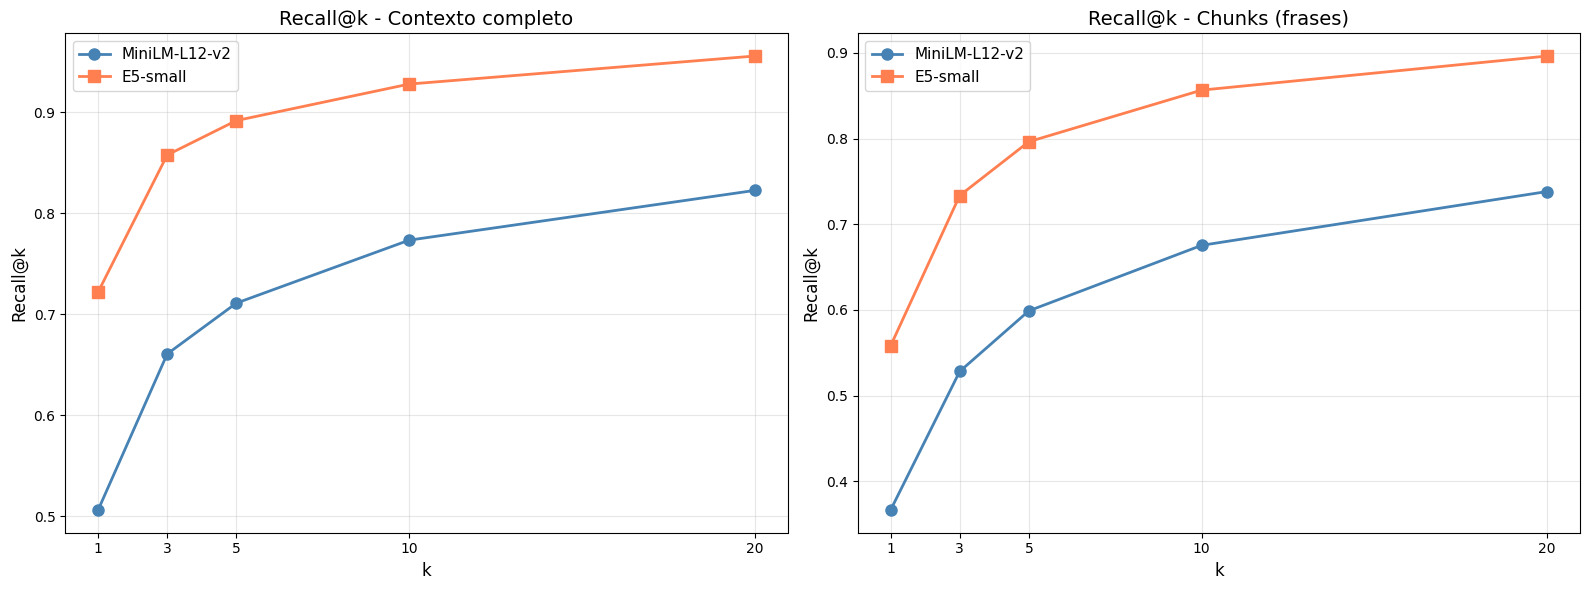

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Contexto completo ---
axes[0].plot(
    k_values,
    [results_model_1[k]["Recall@k"] for k in k_values],
    'o-',
    label='MiniLM-L12-v2',
    color='steelblue',
    linewidth=2,
    markersize=8
)

axes[0].plot(
    k_values,
    [results_model_2[k]["Recall@k"] for k in k_values],
    's-',
    label='E5-small',
    color='coral',
    linewidth=2,
    markersize=8
)

axes[0].set_xlabel('k', fontsize=12)
axes[0].set_ylabel('Recall@k', fontsize=12)
axes[0].set_title('Recall@k - Contexto completo', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(k_values)


# --- Gráfico 2: Chunks ---
axes[1].plot(
    k_values,
    [results_model_1_chunks[k]["Recall@k"] for k in k_values],
    'o-',
    label='MiniLM-L12-v2',
    color='steelblue',
    linewidth=2,
    markersize=8
)

axes[1].plot(
    k_values,
    [results_model_2_chunks[k]["Recall@k"] for k in k_values],
    's-',
    label='E5-small',
    color='coral',
    linewidth=2,
    markersize=8
)

axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('Recall@k', fontsize=12)
axes[1].set_title('Recall@k - Chunks (frases)', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.show()

## Análisis de los resultados

Al comparar ambos modelos podemos observar las diferencias en su rendimiento en la tarea de recuperación semántica sobre el corpus SQAC:

**Contexto completo vs. Chunks (frases):**

- **Mayor dificultad a nivel de chunk**: La recuperación a nivel de frase es significativamente más difícil que a nivel de contexto completo. Esto se debe a dos factores: (1) el corpus de búsqueda es mucho mayor (más candidatos entre los que elegir) y (2) las frases individuales contienen menos señal semántica que los párrafos completos.

**Aspectos a considerar:**

- **Recall@k**: Esta métrica nos indica la proporción de veces que el sistema recupera el contexto correcto entre los *k* primeros resultados. Un valor alto de Recall@k con *k* pequeño indica un sistema más preciso.

- **Diferencias entre modelos**: Los modelos de la familia E5, al estar específicamente entrenados para tareas de recuperación con la distinción explícita entre queries y passages, podrían tener una ventaja en esta tarea frente a modelos de propósito más general como MiniLM.

- **Efecto de k**: A medida que aumenta *k*, el Recall@k naturalmente aumenta (hay más oportunidades de incluir el contexto correcto), pero esto también implica devolver más resultados irrelevantes. El equilibrio entre precisión y cobertura depende de la aplicación.